In [ ]:
# /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/test.png

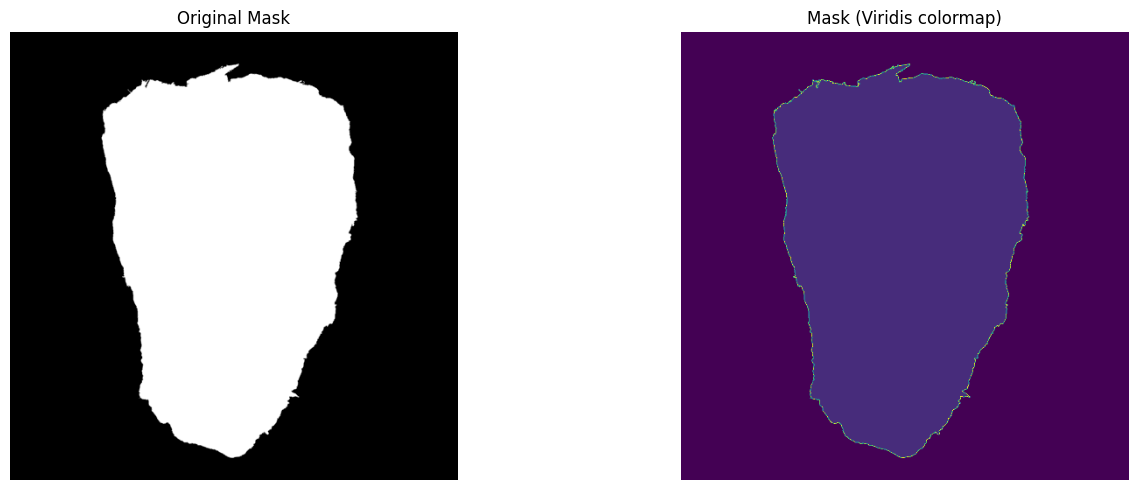

Mask shape: (512, 512)
Mask dtype: uint8
Min value: 0
Max value: 8
Unique values: [0 1 2 3 4 5 6 7 8]
Mean value: 0.39


In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load the mask
mask_path = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/test.png"
mask = Image.open(mask_path)

# Convert to numpy array for analysis
mask_array = np.array(mask)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original mask
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Original Mask')
axes[0].axis('off')

# Mask with different colormap to see details
axes[1].imshow(mask_array, cmap='viridis')
axes[1].set_title('Mask (Viridis colormap)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print mask statistics
print(f"Mask shape: {mask_array.shape}")
print(f"Mask dtype: {mask_array.dtype}")
print(f"Min value: {mask_array.min()}")
print(f"Max value: {mask_array.max()}")
print(f"Unique values: {np.unique(mask_array)}")
print(f"Mean value: {mask_array.mean():.2f}")

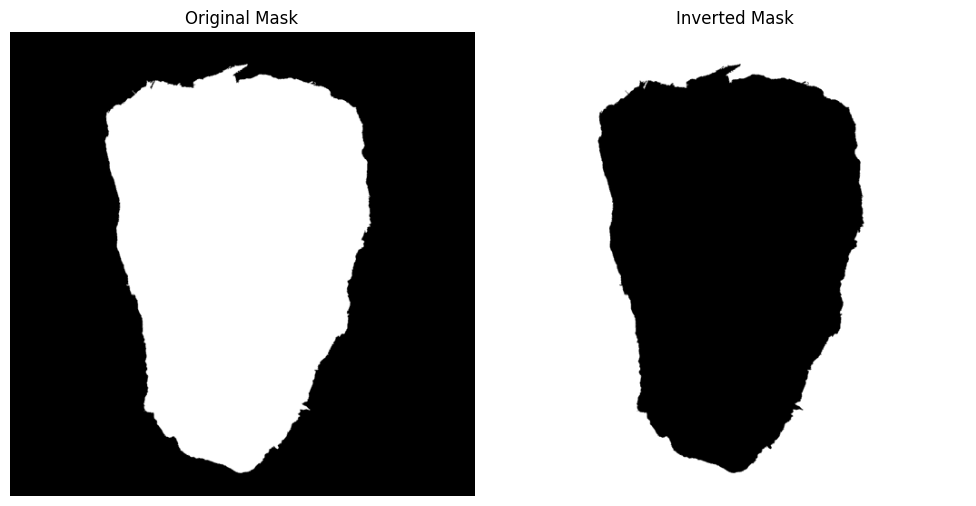

In [7]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Load the image
image_path = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/test.png"
image = Image.open(image_path).convert("L")  # Convert to grayscale

# Invert the image
inverted_image = ImageOps.invert(image)

# Show both original and inverted images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Mask')
axs[0].axis('off')

axs[1].imshow(inverted_image, cmap='gray')
axs[1].set_title('Inverted Mask')
axs[1].axis('off')

plt.tight_layout()
plt.show()


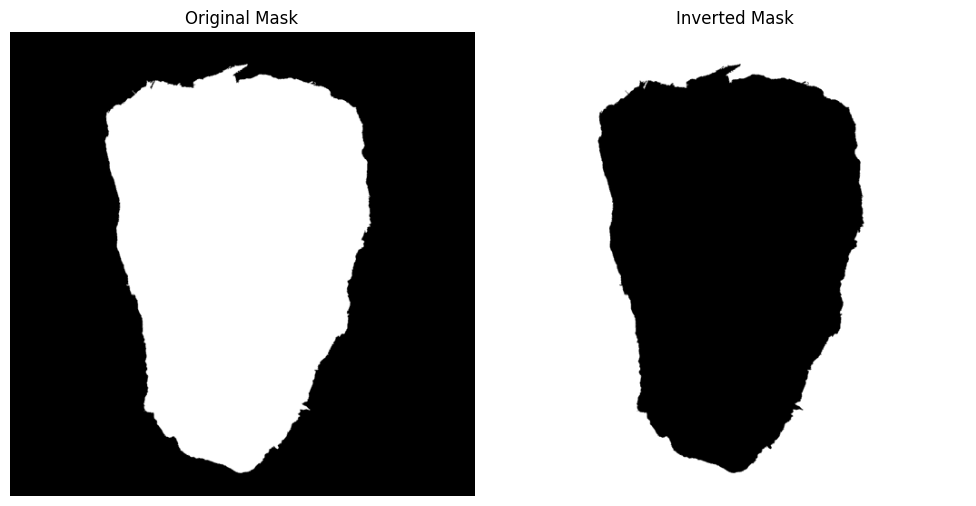

In [11]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Load the image
image_path = "/cluster/home/akmarala/Models/asuka-misato/test.png"
image = Image.open(image_path).convert("L")  # Convert to grayscale

# Invert the image
inverted_image = ImageOps.invert(image)

# Save the inverted image
# output_path = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/test_inverted.png"
# inverted_image.save(output_path)

# Show both original and inverted images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Mask')
axs[0].axis('off')

axs[1].imshow(inverted_image, cmap='gray')
axs[1].set_title('Inverted Mask')
axs[1].axis('off')

plt.tight_layout()
plt.show()

# print(f"Original image size: {image.size}")
# print(f"Inverted image size: {inverted_image.size}")
# print(f"Inverted image saved to: {output_path}")

In [1]:
import os
import shutil
from PIL import Image
from pathlib import Path

# Source and destination paths
source_dir = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/masked_imagenet1k/"
dest_dir = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/"

print("🔄 Moving images from masked_imagenet1k to image directory...")

# Get all JPEG files
jpeg_files = list(Path(source_dir).glob("*.JPEG"))
print(f"Found {len(jpeg_files)} JPEG files")

# Move and convert files
converted_count = 0
for jpeg_file in jpeg_files:
    try:
        # Load image
        img = Image.open(jpeg_file)
        
        # Create PNG filename in destination
        png_filename = jpeg_file.stem + ".png"
        dest_path = Path(dest_dir) / png_filename
        
        # Save as PNG
        img.save(dest_path, "PNG")
        
        # Remove original JPEG only after successful conversion
        jpeg_file.unlink()
        
        converted_count += 1
        if converted_count % 100 == 0:
            print(f"Converted {converted_count} files...")
            
    except Exception as e:
        print(f"Error converting {jpeg_file}: {e}")

print(f"✅ Successfully converted {converted_count} files from JPEG to PNG")

# Verify the results
png_files = list(Path(dest_dir).glob("*.png"))
print(f"Total PNG files in destination: {len(png_files)}")

# Show first few files
print("\nFirst 5 converted files:")
for i, png_file in enumerate(png_files[:5]):
    print(f"  {png_file.name}")

🔄 Moving images from masked_imagenet1k to image directory...
Found 1000 JPEG files
Converted 100 files...
Converted 200 files...
Converted 300 files...
Converted 400 files...
Converted 500 files...
Converted 600 files...
Converted 700 files...
Converted 800 files...
Converted 900 files...
Converted 1000 files...
✅ Successfully converted 1000 files from JPEG to PNG
Total PNG files in destination: 1000

First 5 converted files:
  ILSVRC2012_val_00012416.png
  ILSVRC2012_val_00003380.png
  ILSVRC2012_val_00030840.png
  ILSVRC2012_val_00029836.png
  ILSVRC2012_val_00021497.png


In [2]:
import os
import shutil
from PIL import Image
from pathlib import Path

# Convert ground truth images from JPEG to PNG
source_dir = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/gt/original_datasets/imagenet1k/"
dest_dir = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/gt_image/"

# Create destination directory
os.makedirs(dest_dir, exist_ok=True)

print("🔄 Converting ground truth images from JPEG to PNG...")

# Get all JPEG files
jpeg_files = list(Path(source_dir).glob("*.JPEG"))
print(f"Found {len(jpeg_files)} JPEG files in ground truth directory")

# Convert files
converted_count = 0
for jpeg_file in jpeg_files:
    try:
        # Load image
        img = Image.open(jpeg_file)
        
        # Create PNG filename in destination
        png_filename = jpeg_file.stem + ".png"
        dest_path = Path(dest_dir) / png_filename
        
        # Save as PNG (resize to 512x512 to match other data)
        img_resized = img.resize((512, 512), Image.Resampling.LANCZOS)
        img_resized.save(dest_path, "PNG")
        
        converted_count += 1
        if converted_count % 100 == 0:
            print(f"Converted {converted_count} ground truth files...")
            
    except Exception as e:
        print(f"Error converting {jpeg_file}: {e}")

print(f"✅ Successfully converted {converted_count} ground truth files from JPEG to PNG")

# Verify the results
png_files = list(Path(dest_dir).glob("*.png"))
print(f"Total PNG files in gt_image directory: {len(png_files)}")

# Show first few files
print("\nFirst 5 converted ground truth files:")
for i, png_file in enumerate(png_files[:5]):
    print(f"  {png_file.name}")

print(f"\n📁 Ground truth images saved to: {dest_dir}")

🔄 Converting ground truth images from JPEG to PNG...
Found 1000 JPEG files in ground truth directory
Converted 100 ground truth files...
Converted 200 ground truth files...
Converted 300 ground truth files...
Converted 400 ground truth files...
Converted 500 ground truth files...
Converted 600 ground truth files...
Converted 700 ground truth files...
Converted 800 ground truth files...
Converted 900 ground truth files...
Converted 1000 ground truth files...
✅ Successfully converted 1000 ground truth files from JPEG to PNG
Total PNG files in gt_image directory: 1000

First 5 converted ground truth files:
  ILSVRC2012_val_00016136.png
  ILSVRC2012_val_00028600.png
  ILSVRC2012_val_00006151.png
  ILSVRC2012_val_00022684.png
  ILSVRC2012_val_00024766.png

📁 Ground truth images saved to: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/gt_image/


Dataset Stats:
Total images: 1000
PSNR: 31.594 ± 2.058
SSIM: 0.935 ± 0.021
LPIPS: 0.123 ± 0.076


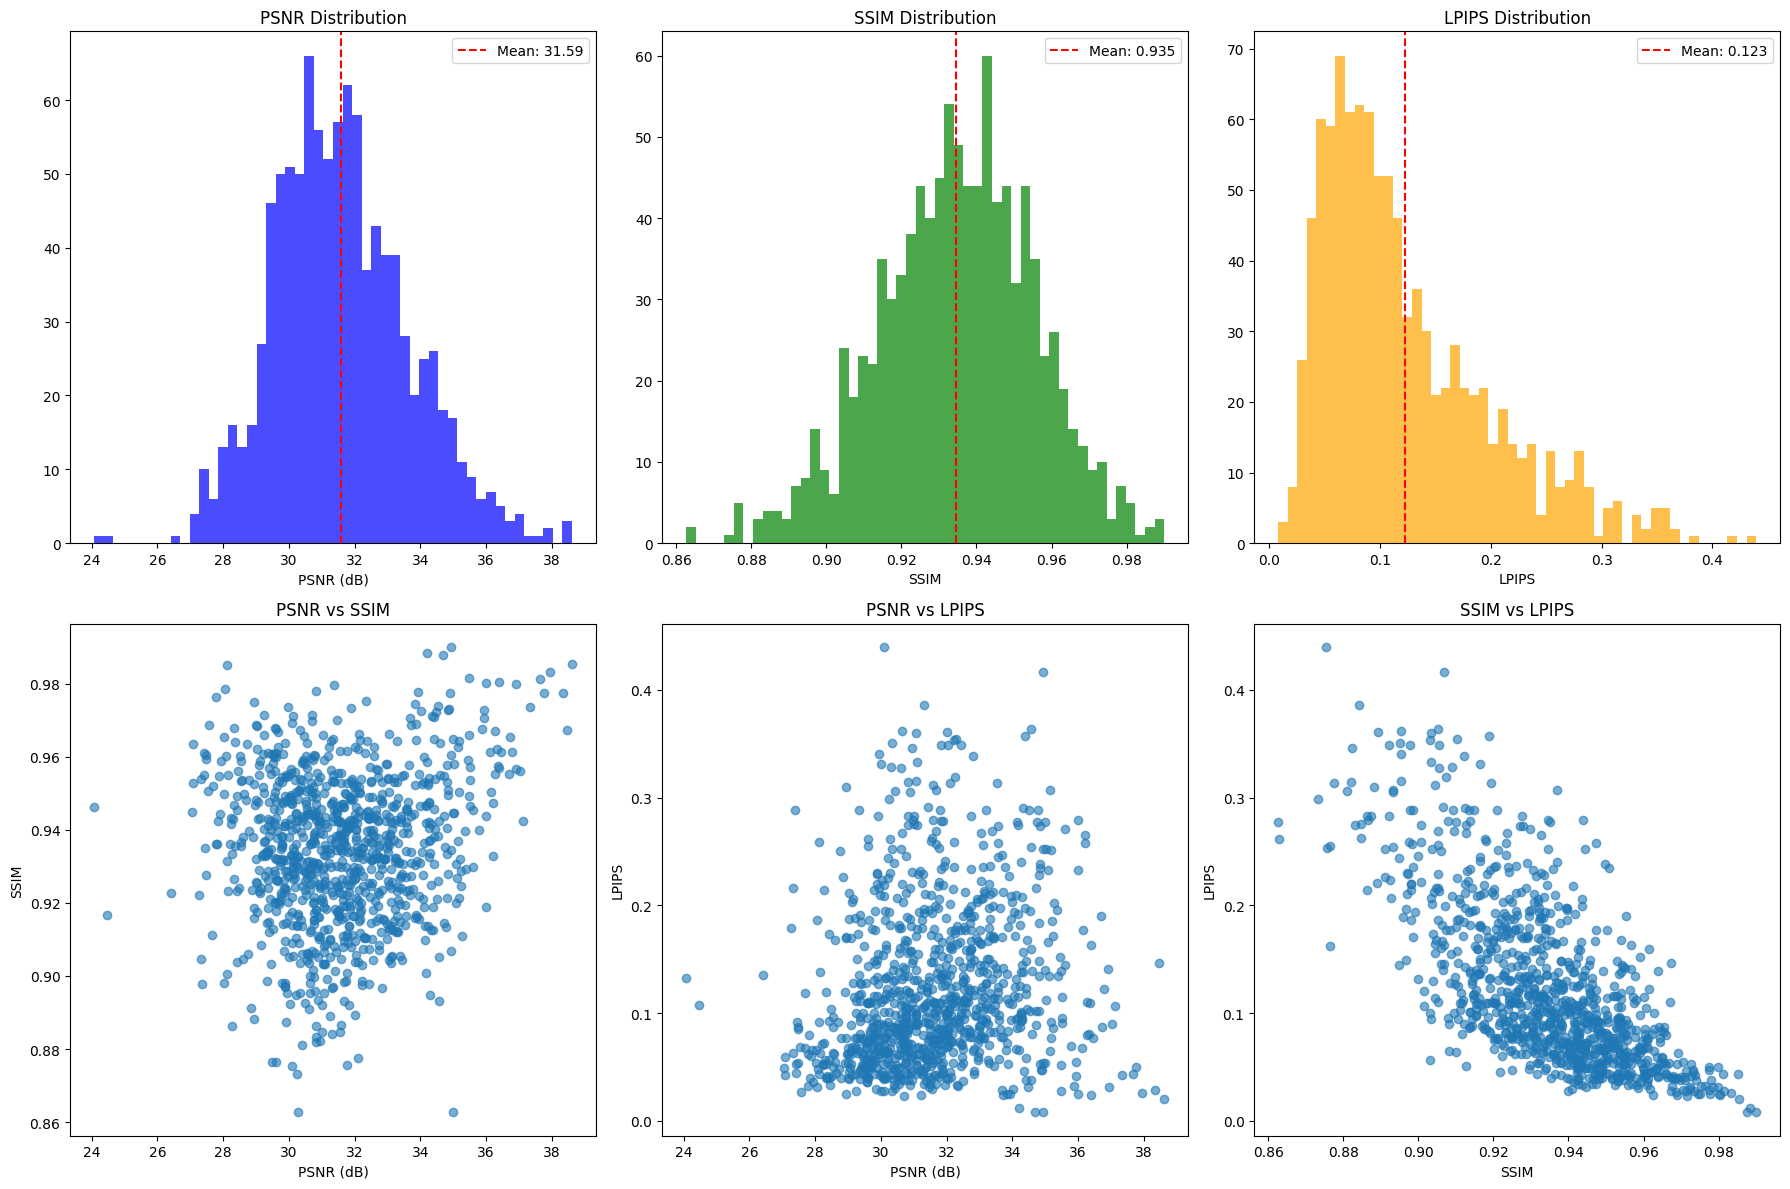


📊 Best PSNR: ILSVRC2012_val_00017080.png - 38.615 dB
📊 Worst PSNR: ILSVRC2012_val_00022541.png - 24.071 dB
📊 Best SSIM: ILSVRC2012_val_00034099.png - 0.990
📊 Worst SSIM: ILSVRC2012_val_00007238.png - 0.863


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the CSV file
df = pd.read_csv('/cluster/home/akmarala/Models/asuka-misato/experiments/exp1_irregular_masking/results/imgs_individual_metrics.csv')

# Clean the LPIPS column (remove the extra brackets)
df['lpips'] = df['lpips'].str.extract(r'(\d+\.\d+)')
df['lpips'] = pd.to_numeric(df['lpips'])

print(f"Dataset Stats:")
print(f"Total images: {len(df)}")
print(f"PSNR: {df['psnr'].mean():.3f} ± {df['psnr'].std():.3f}")
print(f"SSIM: {df['ssim'].mean():.3f} ± {df['ssim'].std():.3f}")
print(f"LPIPS: {df['lpips'].mean():.3f} ± {df['lpips'].std():.3f}")

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Histograms
axes[0,0].hist(df['psnr'], bins=50, alpha=0.7, color='blue')
axes[0,0].set_title('PSNR Distribution')
axes[0,0].set_xlabel('PSNR (dB)')
axes[0,0].axvline(df['psnr'].mean(), color='red', linestyle='--', label=f'Mean: {df["psnr"].mean():.2f}')
axes[0,0].legend()

axes[0,1].hist(df['ssim'], bins=50, alpha=0.7, color='green')
axes[0,1].set_title('SSIM Distribution')
axes[0,1].set_xlabel('SSIM')
axes[0,1].axvline(df['ssim'].mean(), color='red', linestyle='--', label=f'Mean: {df["ssim"].mean():.3f}')
axes[0,1].legend()

axes[0,2].hist(df['lpips'], bins=50, alpha=0.7, color='orange')
axes[0,2].set_title('LPIPS Distribution')
axes[0,2].set_xlabel('LPIPS')
axes[0,2].axvline(df['lpips'].mean(), color='red', linestyle='--', label=f'Mean: {df["lpips"].mean():.3f}')
axes[0,2].legend()

# Scatter plots
axes[1,0].scatter(df['psnr'], df['ssim'], alpha=0.6)
axes[1,0].set_xlabel('PSNR (dB)')
axes[1,0].set_ylabel('SSIM')
axes[1,0].set_title('PSNR vs SSIM')

axes[1,1].scatter(df['psnr'], df['lpips'], alpha=0.6)
axes[1,1].set_xlabel('PSNR (dB)')
axes[1,1].set_ylabel('LPIPS')
axes[1,1].set_title('PSNR vs LPIPS')

axes[1,2].scatter(df['ssim'], df['lpips'], alpha=0.6)
axes[1,2].set_xlabel('SSIM')
axes[1,2].set_ylabel('LPIPS')
axes[1,2].set_title('SSIM vs LPIPS')

plt.tight_layout()
plt.show()

# Find best and worst performers
best_psnr = df.loc[df['psnr'].idxmax()]
worst_psnr = df.loc[df['psnr'].idxmin()]
best_ssim = df.loc[df['ssim'].idxmax()]
worst_ssim = df.loc[df['ssim'].idxmin()]

print(f"\n📊 Best PSNR: {best_psnr['filename']} - {best_psnr['psnr']:.3f} dB")
print(f"📊 Worst PSNR: {worst_psnr['filename']} - {worst_psnr['psnr']:.3f} dB")
print(f"📊 Best SSIM: {best_ssim['filename']} - {best_ssim['ssim']:.3f}")
print(f"📊 Worst SSIM: {worst_ssim['filename']} - {worst_ssim['ssim']:.3f}")

In [8]:
import os
import shutil
from PIL import Image
from pathlib import Path

print("🔄 Setting up Experiment 2: Regular Masking Dataset")

# Clear current data directories (but keep gt_image/image)
print("🧹 Clearing previous experiment data...")
dirs_to_clear = [
    "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/",
    "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/"
]

for dir_path in dirs_to_clear:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path, exist_ok=True)
    print(f"✅ Cleared: {dir_path}")

# Move masks to data/512/mask/
print("\n📁 Moving regular masks...")
mask_source = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/inpainting-exp/regular_masking_results/generated_masks/regularly_generated_masks/"
mask_dest = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/"

if os.path.exists(mask_source):
    mask_files = list(Path(mask_source).glob("*"))
    for mask_file in mask_files:
        if mask_file.is_file():
            shutil.copy2(mask_file, mask_dest)
    print(f"✅ Copied {len(mask_files)} mask files to: {mask_dest}")
else:
    print(f"❌ Mask source not found: {mask_source}")

# Move images to data/512/image/
print("\n🖼️ Moving regular masked images...")
image_source = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/inpainting-exp/regular_masking_results/masked_images/regularly_masked_edges_imagenet1k/"
image_dest = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/"

if os.path.exists(image_source):
    image_files = list(Path(image_source).glob("*"))
    for image_file in image_files:
        if image_file.is_file():
            shutil.copy2(image_file, image_dest)
    print(f"✅ Copied {len(image_files)} image files to: {image_dest}")
else:
    print(f"❌ Image source not found: {image_source}")

# Copy masks to gt_image/mask/ (keeping gt_image/image unchanged)
print("\n🎯 Setting up ground truth masks...")
gt_mask_dest = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/gt_image/mask/"
os.makedirs(gt_mask_dest, exist_ok=True)

# Copy the same masks to gt_image/mask/
if os.path.exists(mask_dest):
    for mask_file in Path(mask_dest).glob("*"):
        if mask_file.is_file():
            shutil.copy2(mask_file, gt_mask_dest)
    print(f"✅ Copied masks to: {gt_mask_dest}")

# Verify the setup
print("\n🔍 Verifying experiment setup...")
mask_count = len(list(Path(mask_dest).glob("*")))
image_count = len(list(Path(image_dest).glob("*")))
gt_image_count = len(list(Path("/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/gt_image/image/").glob("*")))
gt_mask_count = len(list(Path(gt_mask_dest).glob("*")))

print(f"📊 Masks: {mask_count} files")
print(f"📊 Images: {image_count} files")
print(f"📊 GT Images: {gt_image_count} files (unchanged)")
print(f"📊 GT Masks: {gt_mask_count} files")
print(f"🚀 Ready for Experiment 2: Regular Masking!")

# Show first few files
print(f"\nFirst 3 mask files:")
for i, f in enumerate(list(Path(mask_dest).glob("*"))[:3]):
    print(f"  {f.name}")

print(f"\nFirst 3 image files:")
for i, f in enumerate(list(Path(image_dest).glob("*"))[:3]):
    print(f"  {f.name}")

🔄 Setting up Experiment 2: Regular Masking Dataset
🧹 Clearing previous experiment data...
✅ Cleared: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/
✅ Cleared: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/

📁 Moving regular masks...
✅ Copied 1000 mask files to: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/

🖼️ Moving regular masked images...
✅ Copied 1000 image files to: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/

🎯 Setting up ground truth masks...
✅ Copied masks to: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/gt_image/mask/

🔍 Verifying experiment setup...
📊 Masks: 1000 files
📊 Images: 1000 files
📊 GT Images: 1000 files (unchanged)
📊 GT Masks: 1000 files
🚀 Ready for Experiment 2: Regular Masking!

First 3 mask files:
  ILSVRC2012_val_00048828_mask.png
  ILSVRC2012_val_00049990_mask.png
  ILSVRC2012_val_00037775_mask.png

First 3 image files:
  ILSVRC2012_val_00037609.JPEG


In [9]:
import os
import shutil
from PIL import Image
from pathlib import Path

print("🔄 Converting images to PNG format...")

# Directory containing images to convert
image_dir = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/"

# Get all image files (JPEG, JPG, etc.)
image_files = []
for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG']:
    image_files.extend(list(Path(image_dir).glob(ext)))

print(f"Found {len(image_files)} image files to convert")

# Convert files to PNG
converted_count = 0
for image_file in image_files:
    try:
        # Load image
        img = Image.open(image_file)
        
        # Create PNG filename
        png_filename = image_file.stem + ".png"
        dest_path = Path(image_dir) / png_filename
        
        # Save as PNG
        img.save(dest_path, "PNG")
        
        # Remove original file only after successful conversion
        image_file.unlink()
        
        converted_count += 1
        if converted_count % 100 == 0:
            print(f"Converted {converted_count} files...")
            
    except Exception as e:
        print(f"Error converting {image_file}: {e}")

print(f"✅ Successfully converted {converted_count} files to PNG")

# Verify the results
png_files = list(Path(image_dir).glob("*.png"))
print(f"Total PNG files in directory: {len(png_files)}")

# Show first few files
print("\nFirst 5 PNG files:")
for i, png_file in enumerate(png_files[:5]):
    print(f"  {png_file.name}")

🔄 Converting images to PNG format...
Found 1000 image files to convert
Converted 100 files...
Converted 200 files...
Converted 300 files...
Converted 400 files...
Converted 500 files...
Converted 600 files...
Converted 700 files...
Converted 800 files...
Converted 900 files...
Converted 1000 files...
✅ Successfully converted 1000 files to PNG
Total PNG files in directory: 1000

First 5 PNG files:
  ILSVRC2012_val_00016136.png
  ILSVRC2012_val_00028600.png
  ILSVRC2012_val_00006151.png
  ILSVRC2012_val_00022684.png
  ILSVRC2012_val_00024766.png


In [10]:
import os
import shutil
from pathlib import Path

print("🔧 Fixing mask filenames...")

# Directory containing masks with _mask suffix
mask_dir = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/"
gt_mask_dir = "/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/gt_image/mask/"

# Fix mask filenames in both directories
for directory in [mask_dir, gt_mask_dir]:
    print(f"\n📁 Processing: {directory}")
    
    mask_files = list(Path(directory).glob("*_mask.*"))
    print(f"Found {len(mask_files)} files with '_mask' suffix")
    
    renamed_count = 0
    for mask_file in mask_files:
        try:
            # Remove '_mask' from filename
            new_name = mask_file.name.replace('_mask', '')
            new_path = mask_file.parent / new_name
            
            # Rename the file
            mask_file.rename(new_path)
            renamed_count += 1
            
            if renamed_count <= 5:  # Show first 5 examples
                print(f"  {mask_file.name} → {new_name}")
            
        except Exception as e:
            print(f"Error renaming {mask_file}: {e}")
    
    print(f"✅ Renamed {renamed_count} files in {directory}")

# Verify the fix
print(f"\n🔍 Verification:")
mask_files = list(Path(mask_dir).glob("*.png"))
image_files = list(Path("/cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/image/").glob("*.png"))

print(f"Mask files: {len(mask_files)}")
print(f"Image files: {len(image_files)}")

# Check if filenames match now
if mask_files and image_files:
    mask_names = {f.name for f in mask_files}
    image_names = {f.name for f in image_files}
    matches = mask_names.intersection(image_names)
    print(f"Matching filenames: {len(matches)}/{len(image_files)}")
    
    if len(matches) == len(image_files):
        print("🎉 All filenames match! Ready to run inference.")
    else:
        missing = image_names - mask_names
        print(f"❌ Missing masks for: {list(missing)[:5]}...")

🔧 Fixing mask filenames...

📁 Processing: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/
Found 1000 files with '_mask' suffix
  ILSVRC2012_val_00048828_mask.png → ILSVRC2012_val_00048828.png
  ILSVRC2012_val_00049990_mask.png → ILSVRC2012_val_00049990.png
  ILSVRC2012_val_00037775_mask.png → ILSVRC2012_val_00037775.png
  ILSVRC2012_val_00028041_mask.png → ILSVRC2012_val_00028041.png
  ILSVRC2012_val_00013289_mask.png → ILSVRC2012_val_00013289.png
✅ Renamed 1000 files in /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/mask/

📁 Processing: /cluster/home/akmarala/Models/asuka-misato/asuka-flux/data/512/gt_image/mask/
Found 1000 files with '_mask' suffix
  ILSVRC2012_val_00048828_mask.png → ILSVRC2012_val_00048828.png
  ILSVRC2012_val_00049990_mask.png → ILSVRC2012_val_00049990.png
  ILSVRC2012_val_00037775_mask.png → ILSVRC2012_val_00037775.png
  ILSVRC2012_val_00028041_mask.png → ILSVRC2012_val_00028041.png
  ILSVRC2012_val_00013289_mask.png → ILSVRC2

Regular Masking Dataset Stats:
Total images: 1000
PSNR: 33.460 ± 3.056
SSIM: 0.963 ± 0.015
LPIPS: 0.059 ± 0.032


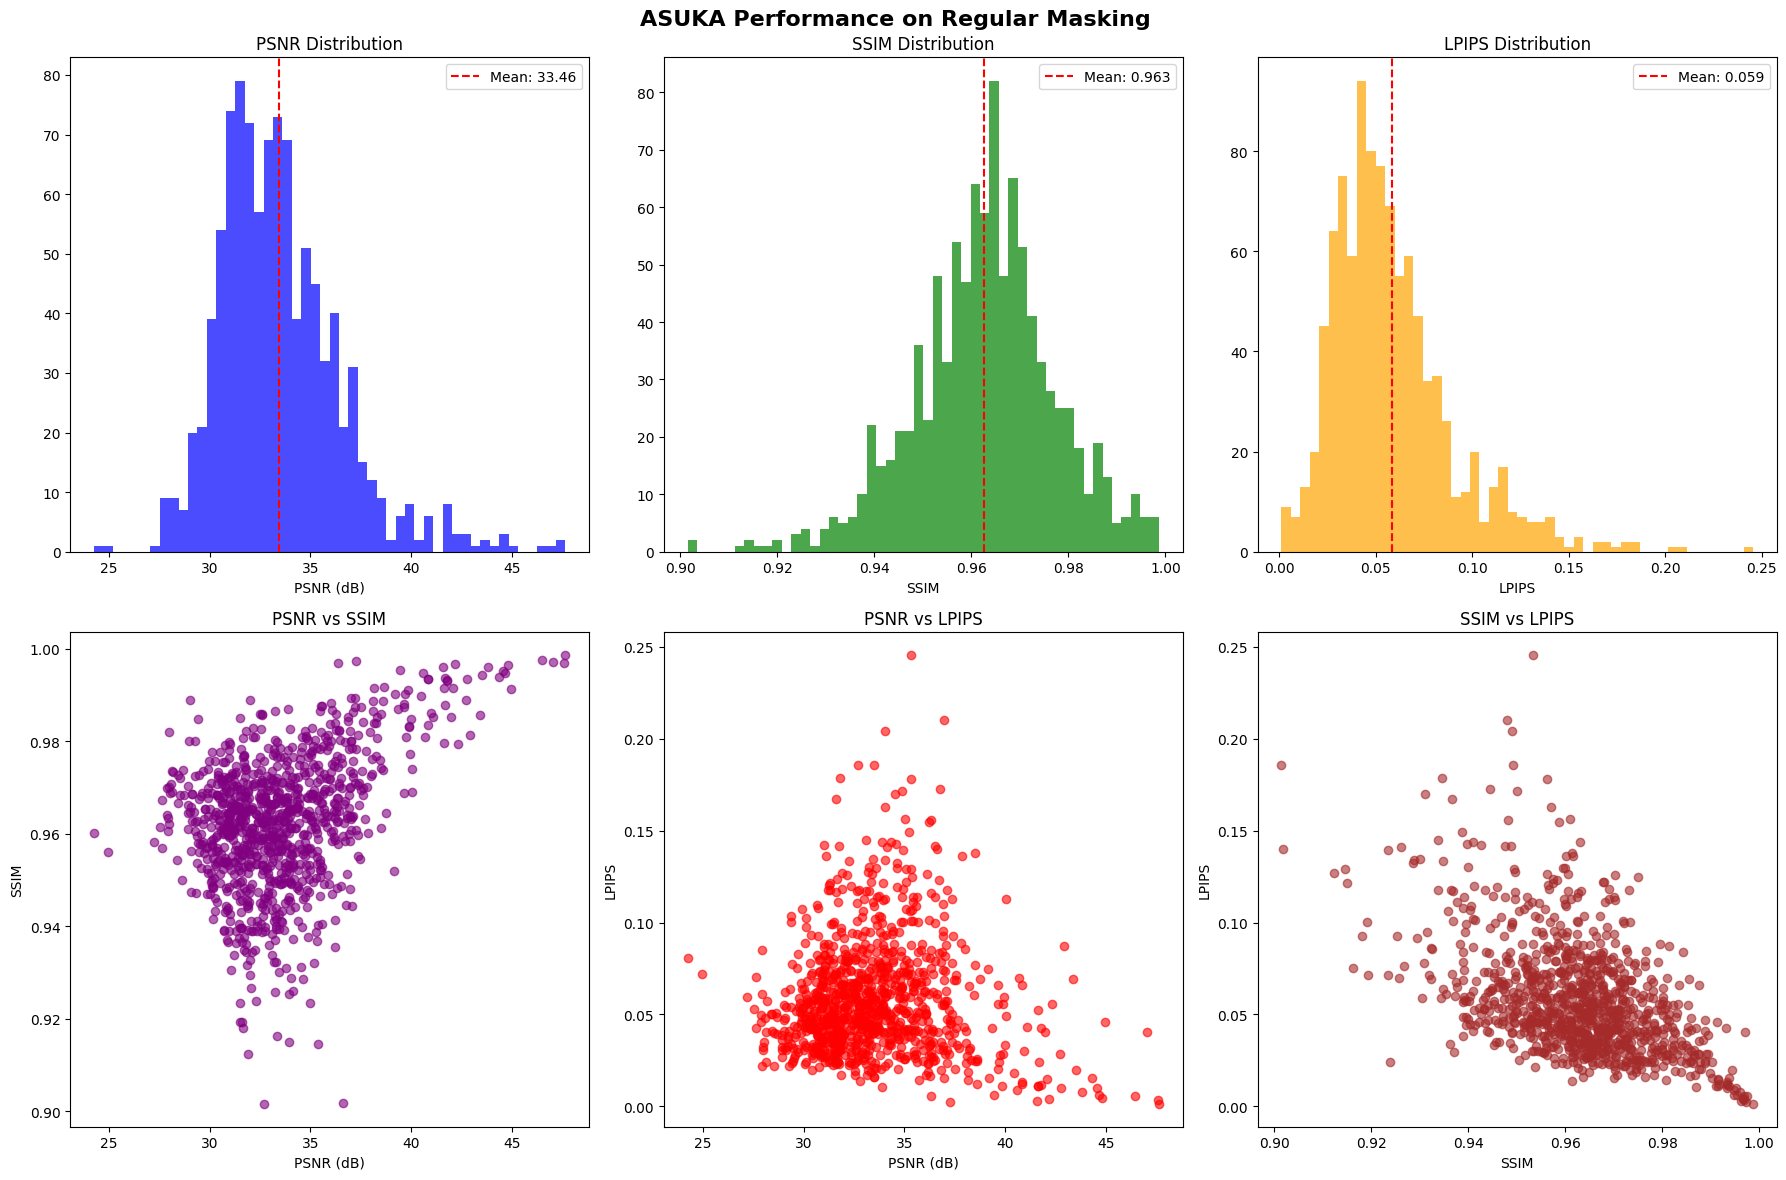


📊 Regular Masking - Best PSNR: ILSVRC2012_val_00013193.png - 47.655 dB
📊 Regular Masking - Worst PSNR: ILSVRC2012_val_00022541.png - 24.238 dB
📊 Regular Masking - Best SSIM: ILSVRC2012_val_00013193.png - 0.999
📊 Regular Masking - Worst SSIM: ILSVRC2012_val_00032802.png - 0.901


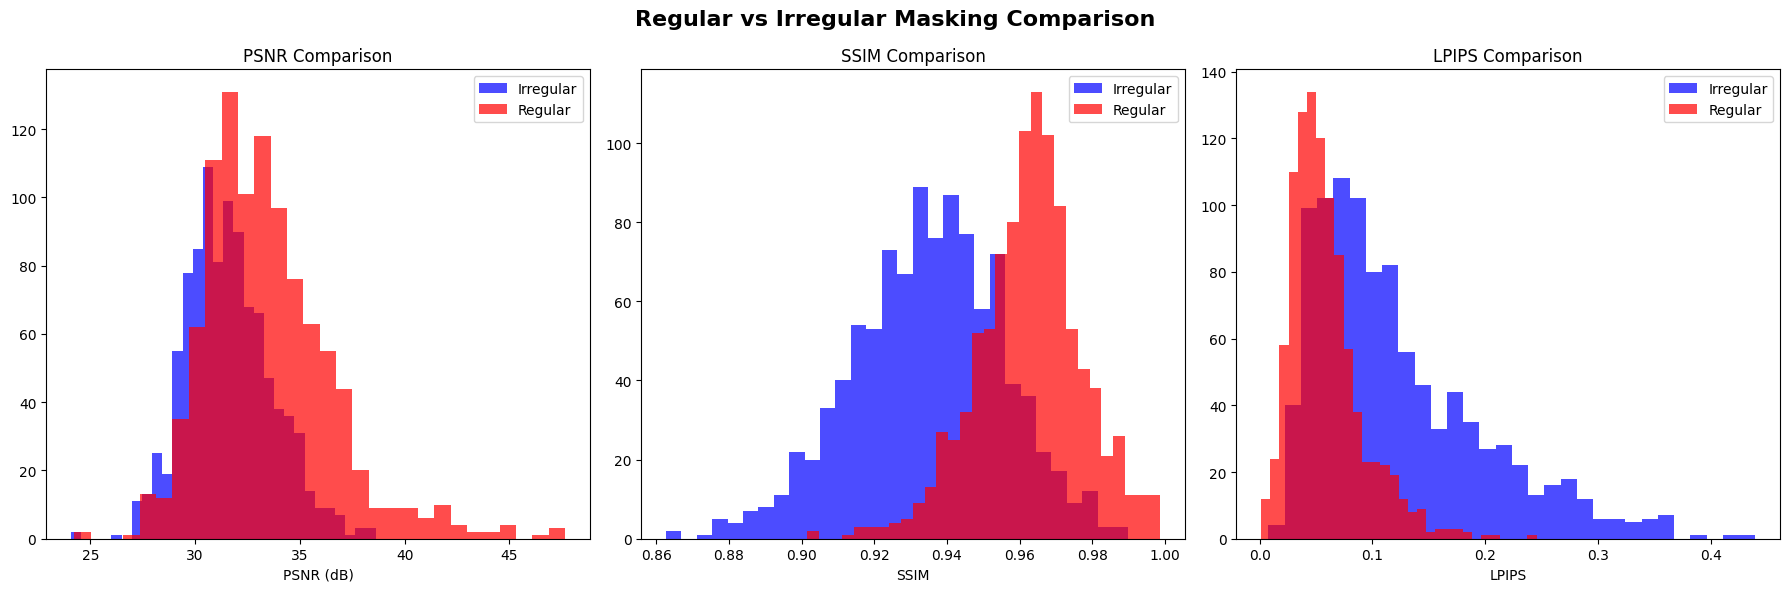


📈 COMPARISON SUMMARY:
Metric     Irregular       Regular         Difference     
PSNR       31.594          33.460          1.866          
SSIM       0.935           0.963           0.028          
LPIPS      0.123           0.059           -0.064         


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the CSV file for regular masking results
df_regular = pd.read_csv('/cluster/home/akmarala/Models/asuka-misato/regular-results/imgs_individual_metrics.csv')

# Clean the LPIPS column (remove the extra brackets if needed)
if df_regular['lpips'].dtype == 'object':
    df_regular['lpips'] = df_regular['lpips'].str.extract(r'(\d+\.\d+)')
    df_regular['lpips'] = pd.to_numeric(df_regular['lpips'])

print(f"Regular Masking Dataset Stats:")
print(f"Total images: {len(df_regular)}")
print(f"PSNR: {df_regular['psnr'].mean():.3f} ± {df_regular['psnr'].std():.3f}")
print(f"SSIM: {df_regular['ssim'].mean():.3f} ± {df_regular['ssim'].std():.3f}")
print(f"LPIPS: {df_regular['lpips'].mean():.3f} ± {df_regular['lpips'].std():.3f}")

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ASUKA Performance on Regular Masking', fontsize=16, fontweight='bold')

# Histograms
axes[0,0].hist(df_regular['psnr'], bins=50, alpha=0.7, color='blue')
axes[0,0].set_title('PSNR Distribution')
axes[0,0].set_xlabel('PSNR (dB)')
axes[0,0].axvline(df_regular['psnr'].mean(), color='red', linestyle='--', label=f'Mean: {df_regular["psnr"].mean():.2f}')
axes[0,0].legend()

axes[0,1].hist(df_regular['ssim'], bins=50, alpha=0.7, color='green')
axes[0,1].set_title('SSIM Distribution')
axes[0,1].set_xlabel('SSIM')
axes[0,1].axvline(df_regular['ssim'].mean(), color='red', linestyle='--', label=f'Mean: {df_regular["ssim"].mean():.3f}')
axes[0,1].legend()

axes[0,2].hist(df_regular['lpips'], bins=50, alpha=0.7, color='orange')
axes[0,2].set_title('LPIPS Distribution')
axes[0,2].set_xlabel('LPIPS')
axes[0,2].axvline(df_regular['lpips'].mean(), color='red', linestyle='--', label=f'Mean: {df_regular["lpips"].mean():.3f}')
axes[0,2].legend()

# Scatter plots
axes[1,0].scatter(df_regular['psnr'], df_regular['ssim'], alpha=0.6, color='purple')
axes[1,0].set_xlabel('PSNR (dB)')
axes[1,0].set_ylabel('SSIM')
axes[1,0].set_title('PSNR vs SSIM')

axes[1,1].scatter(df_regular['psnr'], df_regular['lpips'], alpha=0.6, color='red')
axes[1,1].set_xlabel('PSNR (dB)')
axes[1,1].set_ylabel('LPIPS')
axes[1,1].set_title('PSNR vs LPIPS')

axes[1,2].scatter(df_regular['ssim'], df_regular['lpips'], alpha=0.6, color='brown')
axes[1,2].set_xlabel('SSIM')
axes[1,2].set_ylabel('LPIPS')
axes[1,2].set_title('SSIM vs LPIPS')

plt.tight_layout()
plt.show()

# Find best and worst performers for regular masking
best_psnr = df_regular.loc[df_regular['psnr'].idxmax()]
worst_psnr = df_regular.loc[df_regular['psnr'].idxmin()]
best_ssim = df_regular.loc[df_regular['ssim'].idxmax()]
worst_ssim = df_regular.loc[df_regular['ssim'].idxmin()]

print(f"\n📊 Regular Masking - Best PSNR: {best_psnr['filename']} - {best_psnr['psnr']:.3f} dB")
print(f"📊 Regular Masking - Worst PSNR: {worst_psnr['filename']} - {worst_psnr['psnr']:.3f} dB")
print(f"📊 Regular Masking - Best SSIM: {best_ssim['filename']} - {best_ssim['ssim']:.3f}")
print(f"📊 Regular Masking - Worst SSIM: {worst_ssim['filename']} - {worst_ssim['ssim']:.3f}")

# Comparison with irregular masking (if available)
try:
    df_irregular = pd.read_csv('/cluster/home/akmarala/Models/asuka-misato/experiments/exp1_irregular_masking/results/imgs_individual_metrics.csv')
    
    # Clean LPIPS for irregular data
    if df_irregular['lpips'].dtype == 'object':
        df_irregular['lpips'] = df_irregular['lpips'].str.extract(r'(\d+\.\d+)')
        df_irregular['lpips'] = pd.to_numeric(df_irregular['lpips'])
    
    # Comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Regular vs Irregular Masking Comparison', fontsize=16, fontweight='bold')
    
    # PSNR comparison
    axes[0].hist(df_irregular['psnr'], bins=30, alpha=0.7, color='blue', label='Irregular')
    axes[0].hist(df_regular['psnr'], bins=30, alpha=0.7, color='red', label='Regular')
    axes[0].set_title('PSNR Comparison')
    axes[0].set_xlabel('PSNR (dB)')
    axes[0].legend()
    
    # SSIM comparison
    axes[1].hist(df_irregular['ssim'], bins=30, alpha=0.7, color='blue', label='Irregular')
    axes[1].hist(df_regular['ssim'], bins=30, alpha=0.7, color='red', label='Regular')
    axes[1].set_title('SSIM Comparison')
    axes[1].set_xlabel('SSIM')
    axes[1].legend()
    
    # LPIPS comparison
    axes[2].hist(df_irregular['lpips'], bins=30, alpha=0.7, color='blue', label='Irregular')
    axes[2].hist(df_regular['lpips'], bins=30, alpha=0.7, color='red', label='Regular')
    axes[2].set_title('LPIPS Comparison')
    axes[2].set_xlabel('LPIPS')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison stats
    print(f"\n📈 COMPARISON SUMMARY:")
    print(f"{'Metric':<10} {'Irregular':<15} {'Regular':<15} {'Difference':<15}")
    print(f"{'='*60}")
    print(f"{'PSNR':<10} {df_irregular['psnr'].mean():<15.3f} {df_regular['psnr'].mean():<15.3f} {df_regular['psnr'].mean() - df_irregular['psnr'].mean():<15.3f}")
    print(f"{'SSIM':<10} {df_irregular['ssim'].mean():<15.3f} {df_regular['ssim'].mean():<15.3f} {df_regular['ssim'].mean() - df_irregular['ssim'].mean():<15.3f}")
    print(f"{'LPIPS':<10} {df_irregular['lpips'].mean():<15.3f} {df_regular['lpips'].mean():<15.3f} {df_regular['lpips'].mean() - df_irregular['lpips'].mean():<15.3f}")
    
except FileNotFoundError:
    print("\n⚠️ Irregular masking results not found for comparison")

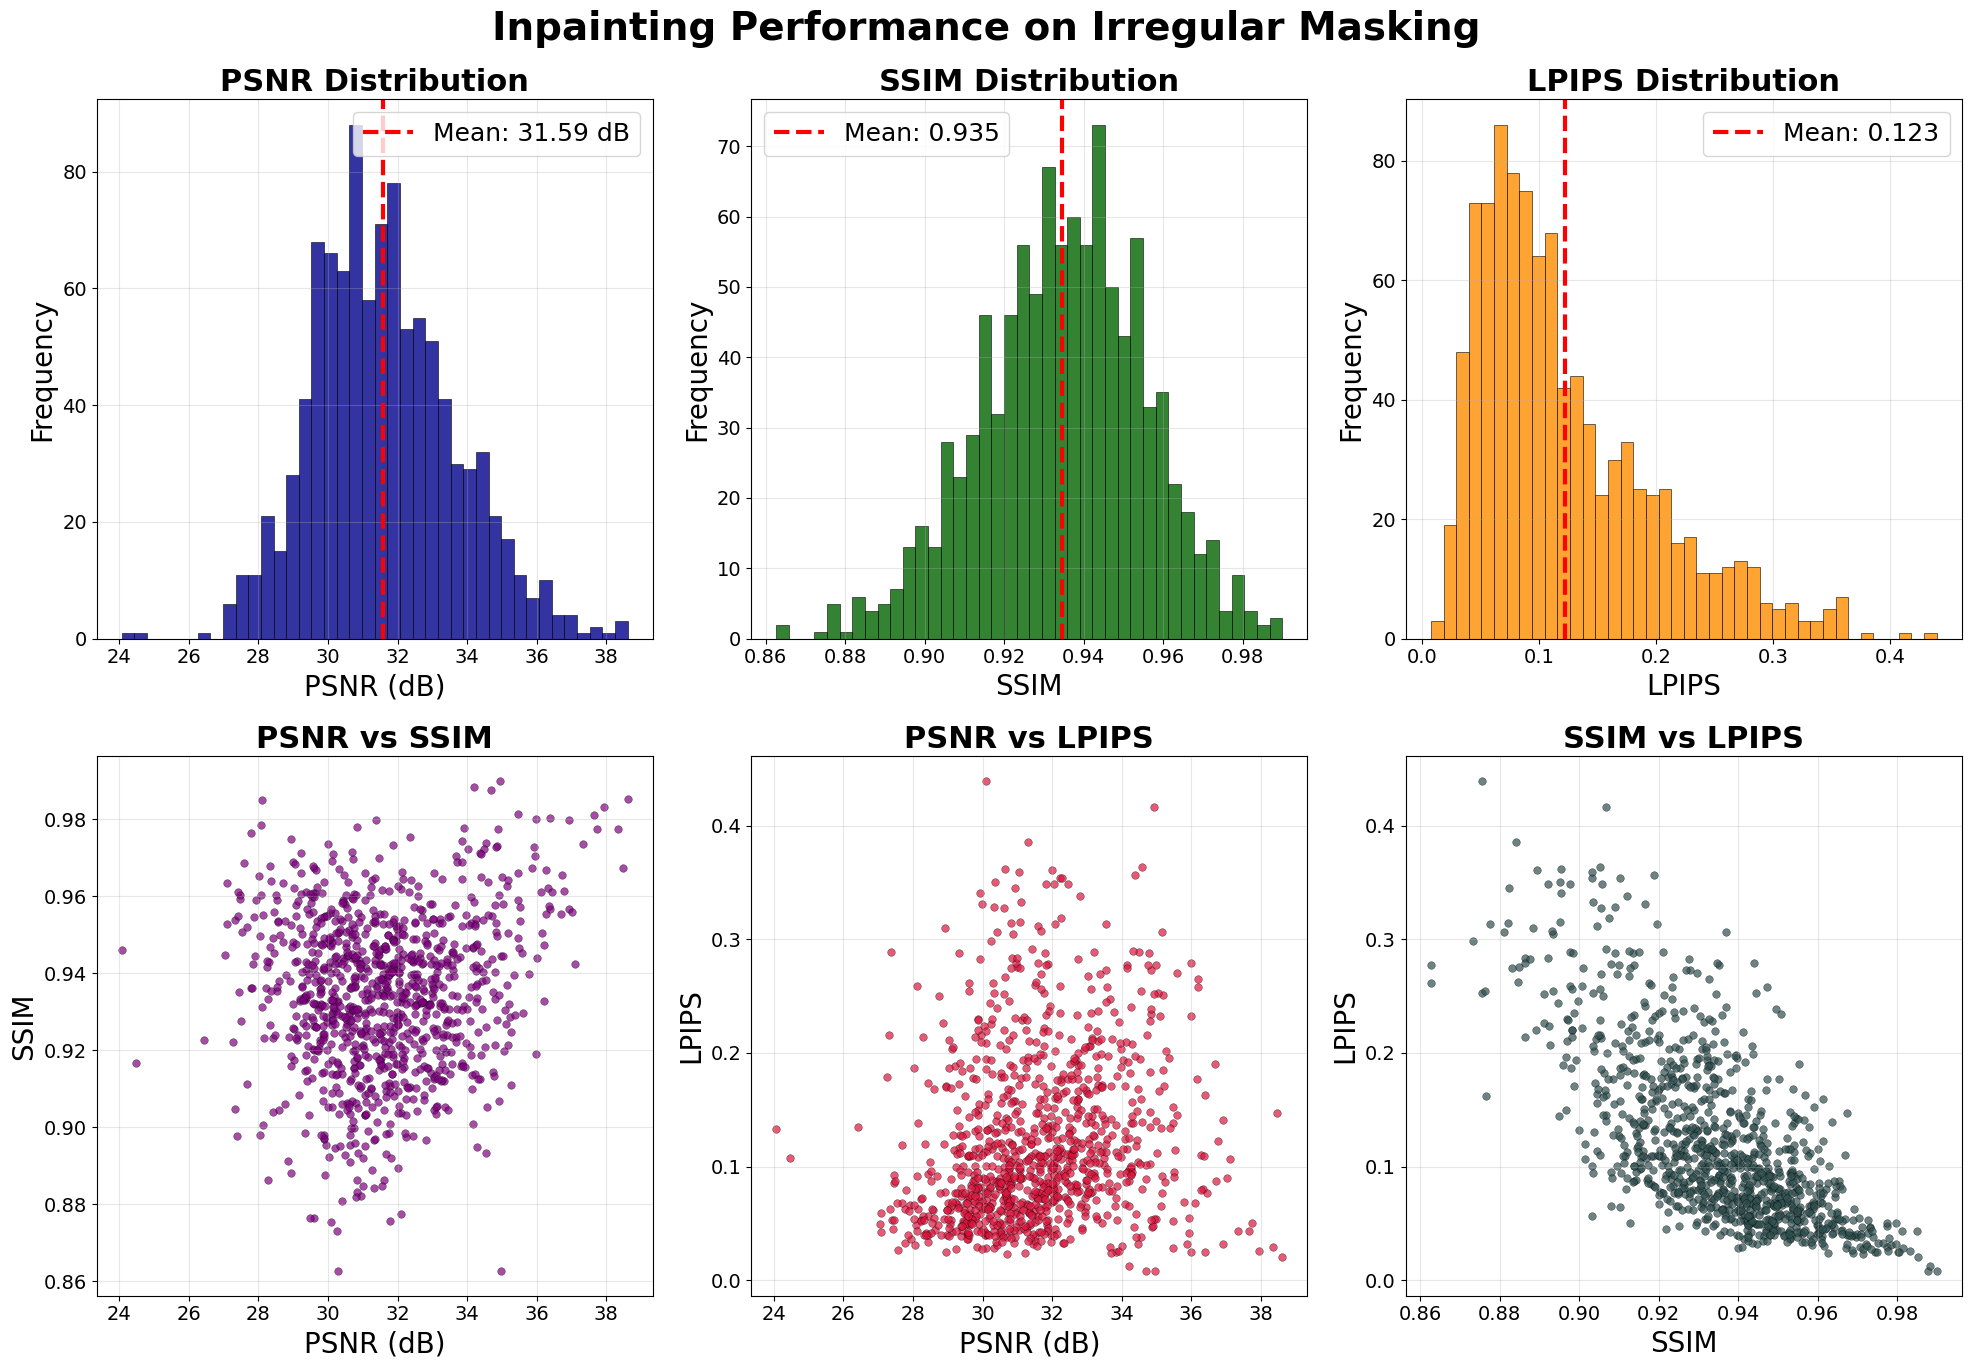

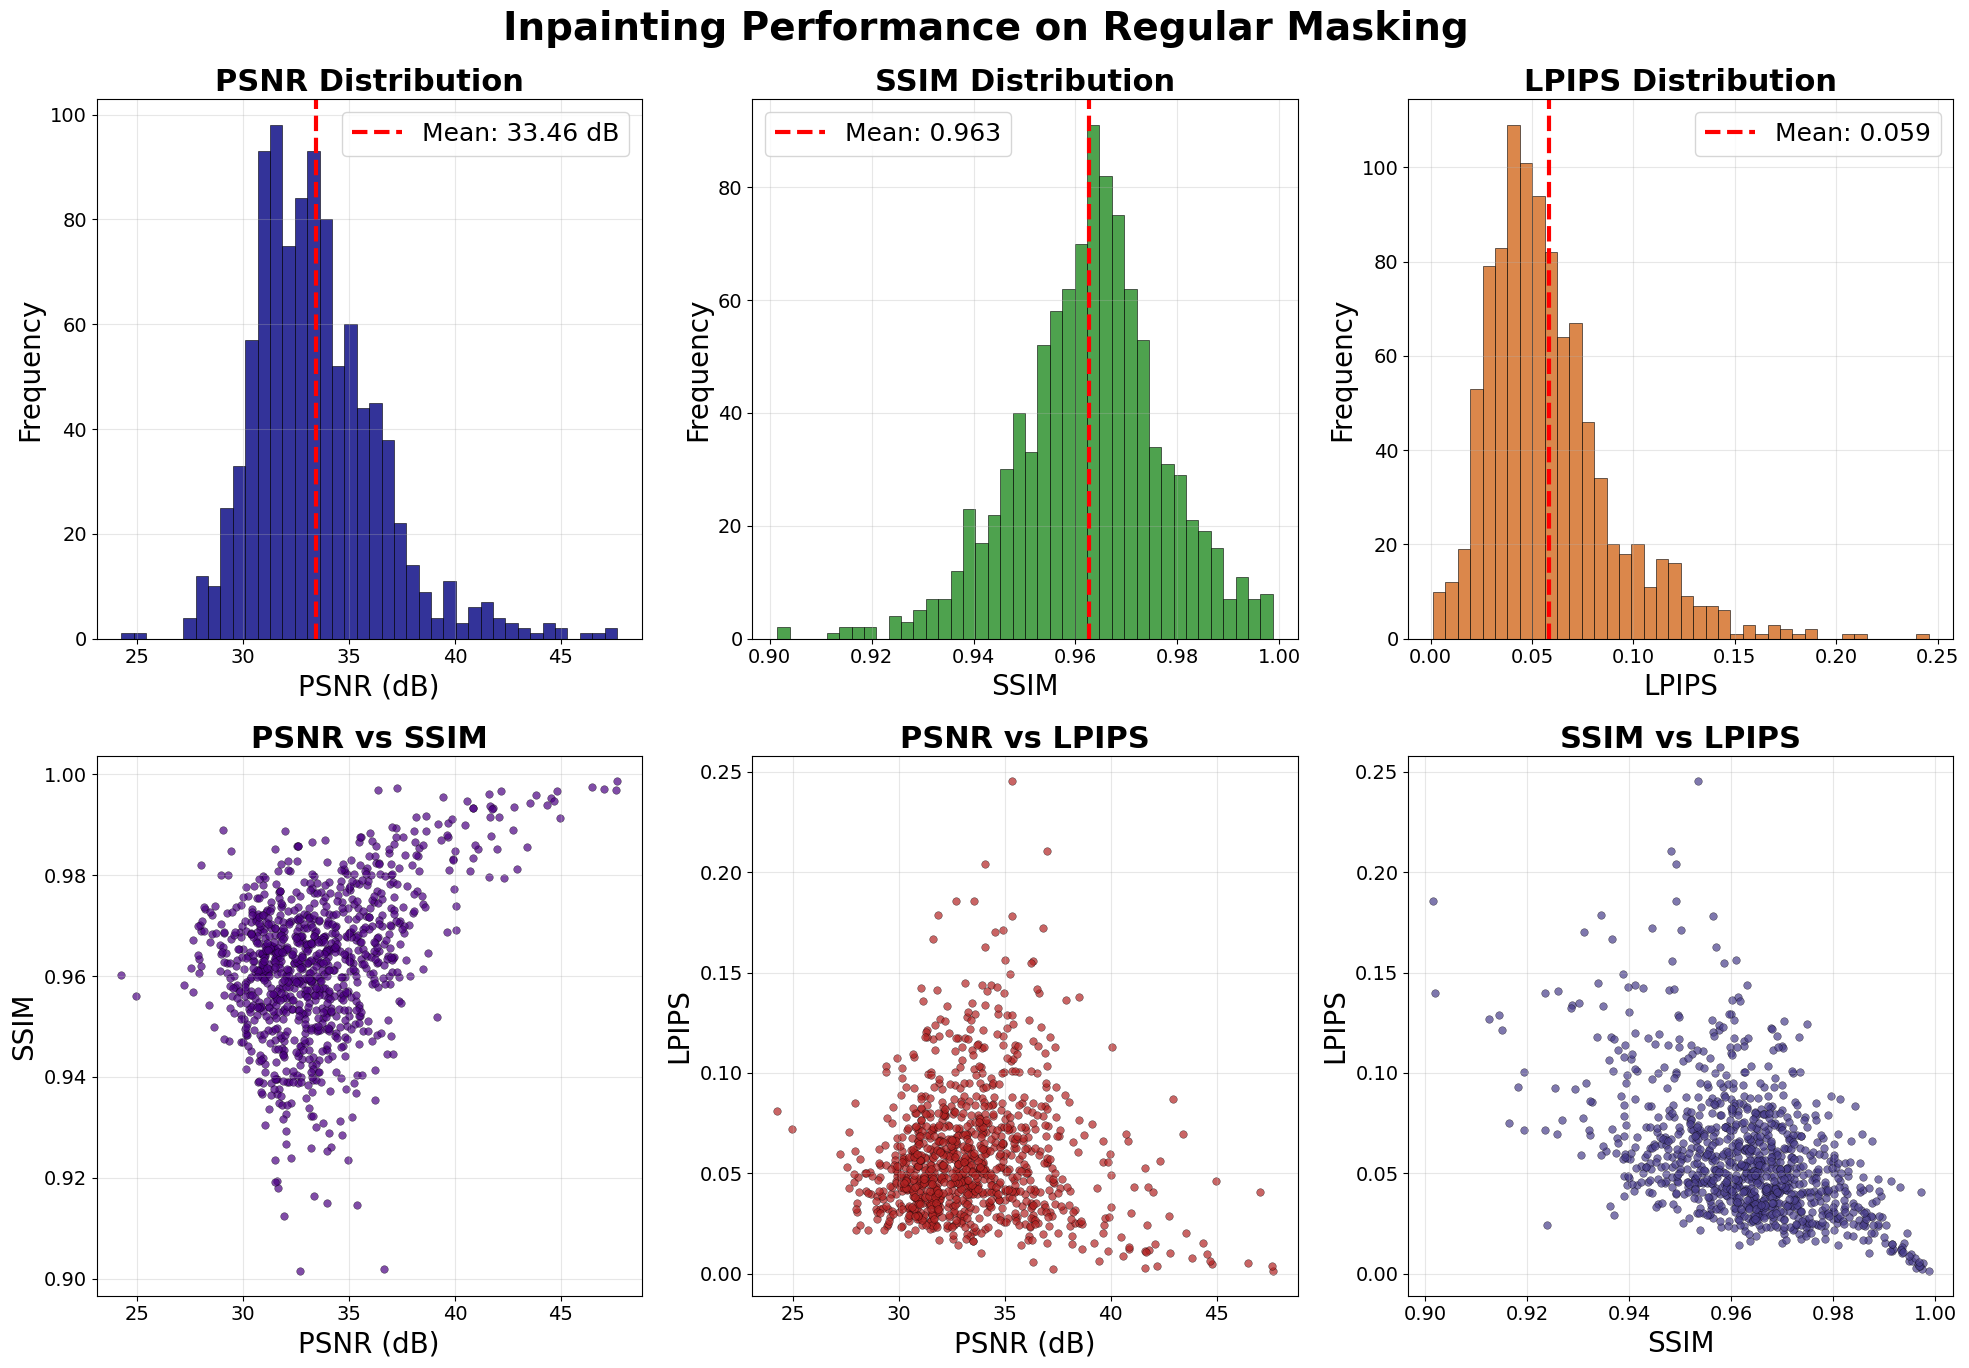

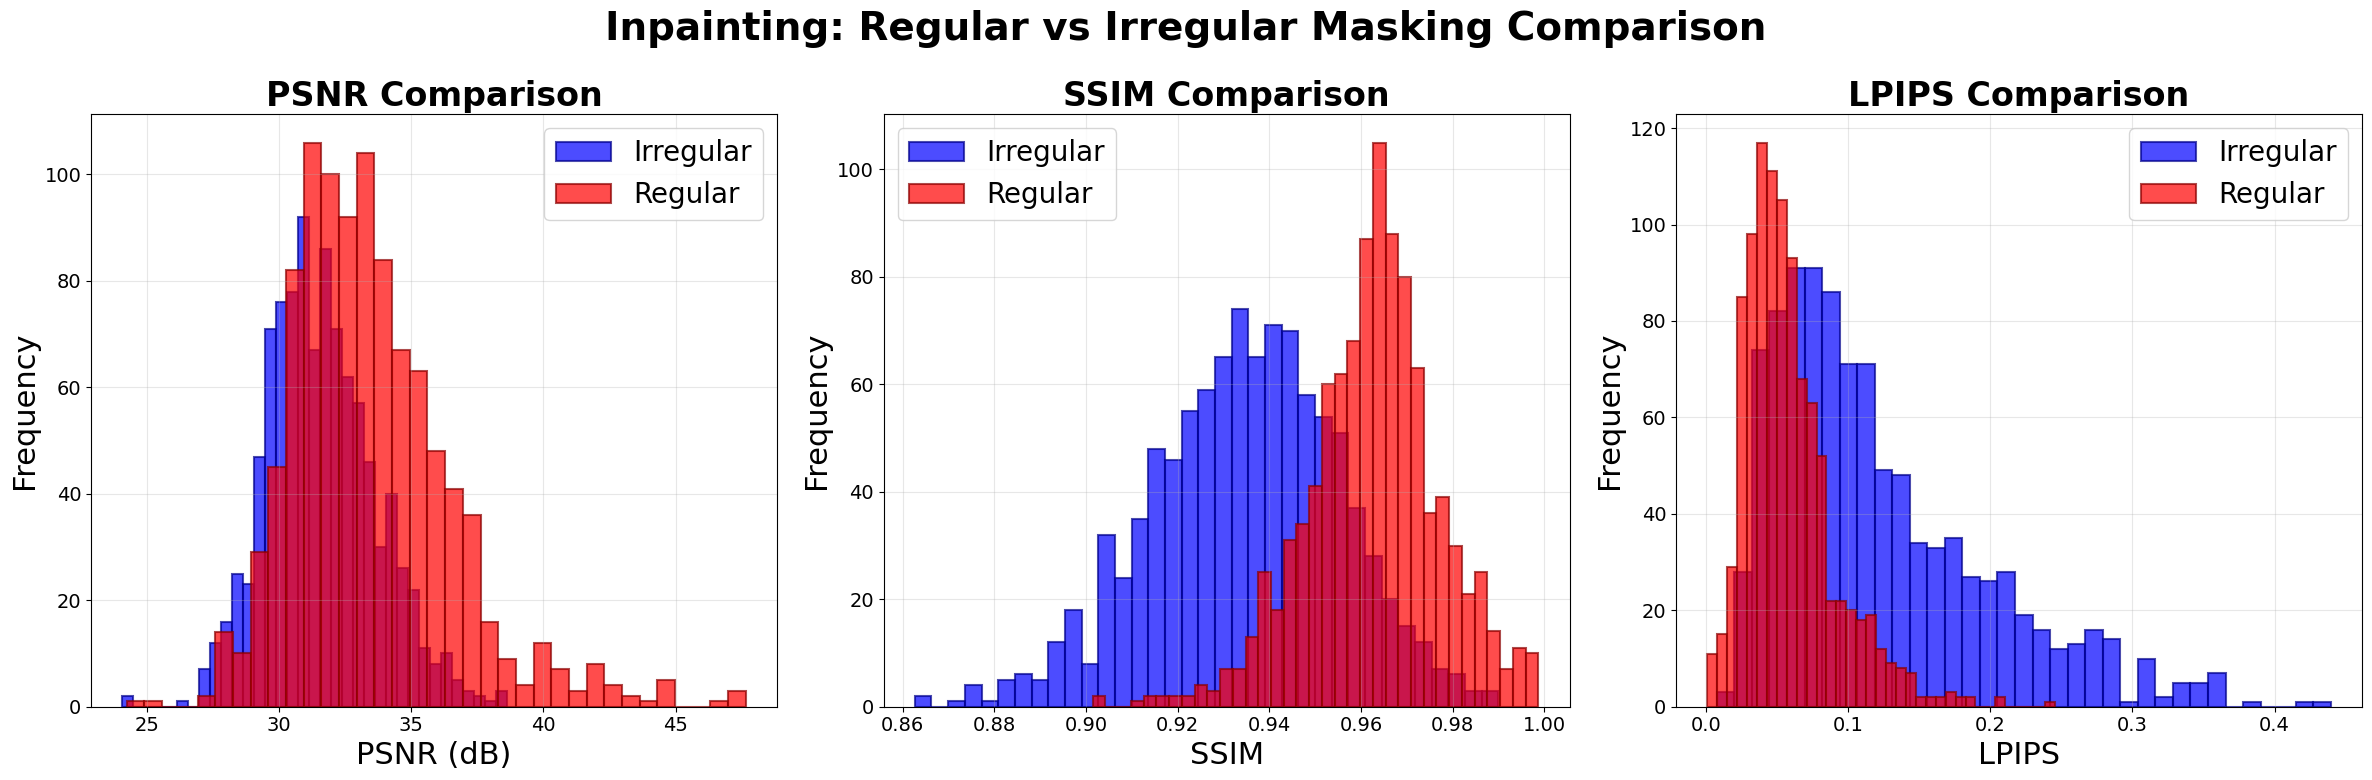

📈 FINAL COMPARISON SUMMARY
Metric       Irregular          Regular            Difference      % Change    
--------------------------------------------------------------------------------
PSNR (dB)    31.594             33.460             1.866           5.90        %
SSIM         0.935              0.963              0.028           3.00        %
LPIPS        0.123              0.059              -0.064          -52.26      %

🎯 KEY FINDINGS:
   • Regular masking achieves 1.87 dB higher PSNR (+5.9%)
   • Regular masking achieves 0.028 higher SSIM (+3.0%)
   • Regular masking achieves 0.064 lower LPIPS (+52.3% better)

📁 Figures saved:
   • Irregular masking: /cluster/home/akmarala/Models/asuka-misato/irregular_masking_results.png
   • Regular masking: /cluster/home/akmarala/Models/asuka-misato/regular_masking_results.png
   • Comparison: /cluster/home/akmarala/Models/asuka-misato/masking_comparison.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style and large font sizes for better readability
plt.style.use('default')
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 24
})

# Load the datasets
df_irregular = pd.read_csv('/cluster/home/akmarala/Models/asuka-misato/experiments/exp1_irregular_masking/results/imgs_individual_metrics.csv')
df_regular = pd.read_csv('/cluster/home/akmarala/Models/asuka-misato/regular-results/imgs_individual_metrics.csv')

# Clean LPIPS columns
if df_irregular['lpips'].dtype == 'object':
    df_irregular['lpips'] = df_irregular['lpips'].str.extract(r'(\d+\.\d+)')
    df_irregular['lpips'] = pd.to_numeric(df_irregular['lpips'])

if df_regular['lpips'].dtype == 'object':
    df_regular['lpips'] = df_regular['lpips'].str.extract(r'(\d+\.\d+)')
    df_regular['lpips'] = pd.to_numeric(df_regular['lpips'])

# ================================
# FIGURE 1: IRREGULAR MASKING
# ================================
fig1, axes1 = plt.subplots(2, 3, figsize=(20, 14))
fig1.suptitle('Inpainting Performance on Irregular Masking', fontsize=28, fontweight='bold', y=0.98)

# Histograms
axes1[0,0].hist(df_irregular['psnr'], bins=40, alpha=0.8, color='darkblue', edgecolor='black', linewidth=0.5)
axes1[0,0].set_title('PSNR Distribution', fontsize=22, fontweight='bold')
axes1[0,0].set_xlabel('PSNR (dB)', fontsize=20)
axes1[0,0].set_ylabel('Frequency', fontsize=20)
axes1[0,0].axvline(df_irregular['psnr'].mean(), color='red', linestyle='--', linewidth=3, 
                   label=f'Mean: {df_irregular["psnr"].mean():.2f} dB')
axes1[0,0].legend(fontsize=18)
axes1[0,0].grid(True, alpha=0.3)

axes1[0,1].hist(df_irregular['ssim'], bins=40, alpha=0.8, color='darkgreen', edgecolor='black', linewidth=0.5)
axes1[0,1].set_title('SSIM Distribution', fontsize=22, fontweight='bold')
axes1[0,1].set_xlabel('SSIM', fontsize=20)
axes1[0,1].set_ylabel('Frequency', fontsize=20)
axes1[0,1].axvline(df_irregular['ssim'].mean(), color='red', linestyle='--', linewidth=3,
                   label=f'Mean: {df_irregular["ssim"].mean():.3f}')
axes1[0,1].legend(fontsize=18)
axes1[0,1].grid(True, alpha=0.3)

axes1[0,2].hist(df_irregular['lpips'], bins=40, alpha=0.8, color='darkorange', edgecolor='black', linewidth=0.5)
axes1[0,2].set_title('LPIPS Distribution', fontsize=22, fontweight='bold')
axes1[0,2].set_xlabel('LPIPS', fontsize=20)
axes1[0,2].set_ylabel('Frequency', fontsize=20)
axes1[0,2].axvline(df_irregular['lpips'].mean(), color='red', linestyle='--', linewidth=3,
                   label=f'Mean: {df_irregular["lpips"].mean():.3f}')
axes1[0,2].legend(fontsize=18)
axes1[0,2].grid(True, alpha=0.3)

# Scatter plots
axes1[1,0].scatter(df_irregular['psnr'], df_irregular['ssim'], alpha=0.7, s=30, color='purple', edgecolors='black', linewidth=0.3)
axes1[1,0].set_xlabel('PSNR (dB)', fontsize=20)
axes1[1,0].set_ylabel('SSIM', fontsize=20)
axes1[1,0].set_title('PSNR vs SSIM', fontsize=22, fontweight='bold')
axes1[1,0].grid(True, alpha=0.3)

axes1[1,1].scatter(df_irregular['psnr'], df_irregular['lpips'], alpha=0.7, s=30, color='crimson', edgecolors='black', linewidth=0.3)
axes1[1,1].set_xlabel('PSNR (dB)', fontsize=20)
axes1[1,1].set_ylabel('LPIPS', fontsize=20)
axes1[1,1].set_title('PSNR vs LPIPS', fontsize=22, fontweight='bold')
axes1[1,1].grid(True, alpha=0.3)

axes1[1,2].scatter(df_irregular['ssim'], df_irregular['lpips'], alpha=0.7, s=30, color='darkslategray', edgecolors='black', linewidth=0.3)
axes1[1,2].set_xlabel('SSIM', fontsize=20)
axes1[1,2].set_ylabel('LPIPS', fontsize=20)
axes1[1,2].set_title('SSIM vs LPIPS', fontsize=22, fontweight='bold')
axes1[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/cluster/home/akmarala/Models/asuka-misato/irregular_masking_results.png', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ================================
# FIGURE 2: REGULAR MASKING
# ================================
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 14))
fig2.suptitle('Inpainting Performance on Regular Masking', fontsize=28, fontweight='bold', y=0.98)

# Histograms
axes2[0,0].hist(df_regular['psnr'], bins=40, alpha=0.8, color='navy', edgecolor='black', linewidth=0.5)
axes2[0,0].set_title('PSNR Distribution', fontsize=22, fontweight='bold')
axes2[0,0].set_xlabel('PSNR (dB)', fontsize=20)
axes2[0,0].set_ylabel('Frequency', fontsize=20)
axes2[0,0].axvline(df_regular['psnr'].mean(), color='red', linestyle='--', linewidth=3,
                   label=f'Mean: {df_regular["psnr"].mean():.2f} dB')
axes2[0,0].legend(fontsize=18)
axes2[0,0].grid(True, alpha=0.3)

axes2[0,1].hist(df_regular['ssim'], bins=40, alpha=0.8, color='forestgreen', edgecolor='black', linewidth=0.5)
axes2[0,1].set_title('SSIM Distribution', fontsize=22, fontweight='bold')
axes2[0,1].set_xlabel('SSIM', fontsize=20)
axes2[0,1].set_ylabel('Frequency', fontsize=20)
axes2[0,1].axvline(df_regular['ssim'].mean(), color='red', linestyle='--', linewidth=3,
                   label=f'Mean: {df_regular["ssim"].mean():.3f}')
axes2[0,1].legend(fontsize=18)
axes2[0,1].grid(True, alpha=0.3)

axes2[0,2].hist(df_regular['lpips'], bins=40, alpha=0.8, color='chocolate', edgecolor='black', linewidth=0.5)
axes2[0,2].set_title('LPIPS Distribution', fontsize=22, fontweight='bold')
axes2[0,2].set_xlabel('LPIPS', fontsize=20)
axes2[0,2].set_ylabel('Frequency', fontsize=20)
axes2[0,2].axvline(df_regular['lpips'].mean(), color='red', linestyle='--', linewidth=3,
                   label=f'Mean: {df_regular["lpips"].mean():.3f}')
axes2[0,2].legend(fontsize=18)
axes2[0,2].grid(True, alpha=0.3)

# Scatter plots
axes2[1,0].scatter(df_regular['psnr'], df_regular['ssim'], alpha=0.7, s=30, color='indigo', edgecolors='black', linewidth=0.3)
axes2[1,0].set_xlabel('PSNR (dB)', fontsize=20)
axes2[1,0].set_ylabel('SSIM', fontsize=20)
axes2[1,0].set_title('PSNR vs SSIM', fontsize=22, fontweight='bold')
axes2[1,0].grid(True, alpha=0.3)

axes2[1,1].scatter(df_regular['psnr'], df_regular['lpips'], alpha=0.7, s=30, color='firebrick', edgecolors='black', linewidth=0.3)
axes2[1,1].set_xlabel('PSNR (dB)', fontsize=20)
axes2[1,1].set_ylabel('LPIPS', fontsize=20)
axes2[1,1].set_title('PSNR vs LPIPS', fontsize=22, fontweight='bold')
axes2[1,1].grid(True, alpha=0.3)

axes2[1,2].scatter(df_regular['ssim'], df_regular['lpips'], alpha=0.7, s=30, color='darkslateblue', edgecolors='black', linewidth=0.3)
axes2[1,2].set_xlabel('SSIM', fontsize=20)
axes2[1,2].set_ylabel('LPIPS', fontsize=20)
axes2[1,2].set_title('SSIM vs LPIPS', fontsize=22, fontweight='bold')
axes2[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/cluster/home/akmarala/Models/asuka-misato/regular_masking_results.png', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ================================
# FIGURE 3: COMPARISON
# ================================
fig3, axes3 = plt.subplots(1, 3, figsize=(24, 8))
fig3.suptitle('Inpainting: Regular vs Irregular Masking Comparison', fontsize=28, fontweight='bold', y=0.98)

# PSNR comparison
axes3[0].hist(df_irregular['psnr'], bins=35, alpha=0.7, color='blue', label='Irregular', 
              edgecolor='darkblue', linewidth=1.5)
axes3[0].hist(df_regular['psnr'], bins=35, alpha=0.7, color='red', label='Regular',
              edgecolor='darkred', linewidth=1.5)
axes3[0].set_title('PSNR Comparison', fontsize=24, fontweight='bold')
axes3[0].set_xlabel('PSNR (dB)', fontsize=22)
axes3[0].set_ylabel('Frequency', fontsize=22)
axes3[0].legend(fontsize=20)
axes3[0].grid(True, alpha=0.3)

# SSIM comparison
axes3[1].hist(df_irregular['ssim'], bins=35, alpha=0.7, color='blue', label='Irregular',
              edgecolor='darkblue', linewidth=1.5)
axes3[1].hist(df_regular['ssim'], bins=35, alpha=0.7, color='red', label='Regular',
              edgecolor='darkred', linewidth=1.5)
axes3[1].set_title('SSIM Comparison', fontsize=24, fontweight='bold')
axes3[1].set_xlabel('SSIM', fontsize=22)
axes3[1].set_ylabel('Frequency', fontsize=22)
axes3[1].legend(fontsize=20)
axes3[1].grid(True, alpha=0.3)

# LPIPS comparison
axes3[2].hist(df_irregular['lpips'], bins=35, alpha=0.7, color='blue', label='Irregular',
              edgecolor='darkblue', linewidth=1.5)
axes3[2].hist(df_regular['lpips'], bins=35, alpha=0.7, color='red', label='Regular',
              edgecolor='darkred', linewidth=1.5)
axes3[2].set_title('LPIPS Comparison', fontsize=24, fontweight='bold')
axes3[2].set_xlabel('LPIPS', fontsize=22)
axes3[2].set_ylabel('Frequency', fontsize=22)
axes3[2].legend(fontsize=20)
axes3[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/cluster/home/akmarala/Models/asuka-misato/masking_comparison.png', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Print summary statistics
print("="*80)
print("📈 FINAL COMPARISON SUMMARY")
print("="*80)
print(f"{'Metric':<12} {'Irregular':<18} {'Regular':<18} {'Difference':<15} {'% Change':<12}")
print("-"*80)

psnr_diff = df_regular['psnr'].mean() - df_irregular['psnr'].mean()
psnr_pct = (psnr_diff / df_irregular['psnr'].mean()) * 100

ssim_diff = df_regular['ssim'].mean() - df_irregular['ssim'].mean()
ssim_pct = (ssim_diff / df_irregular['ssim'].mean()) * 100

lpips_diff = df_regular['lpips'].mean() - df_irregular['lpips'].mean()
lpips_pct = (lpips_diff / df_irregular['lpips'].mean()) * 100

print(f"{'PSNR (dB)':<12} {df_irregular['psnr'].mean():<18.3f} {df_regular['psnr'].mean():<18.3f} {psnr_diff:<15.3f} {psnr_pct:<12.2f}%")
print(f"{'SSIM':<12} {df_irregular['ssim'].mean():<18.3f} {df_regular['ssim'].mean():<18.3f} {ssim_diff:<15.3f} {ssim_pct:<12.2f}%")
print(f"{'LPIPS':<12} {df_irregular['lpips'].mean():<18.3f} {df_regular['lpips'].mean():<18.3f} {lpips_diff:<15.3f} {lpips_pct:<12.2f}%")

print("\n🎯 KEY FINDINGS:")
if psnr_diff > 0:
    print(f"   • Regular masking achieves {psnr_diff:.2f} dB higher PSNR ({psnr_pct:+.1f}%)")
else:
    print(f"   • Irregular masking achieves {abs(psnr_diff):.2f} dB higher PSNR ({abs(psnr_pct):+.1f}%)")

if ssim_diff > 0:
    print(f"   • Regular masking achieves {ssim_diff:.3f} higher SSIM ({ssim_pct:+.1f}%)")
else:
    print(f"   • Irregular masking achieves {abs(ssim_diff):.3f} higher SSIM ({abs(ssim_pct):+.1f}%)")

if lpips_diff < 0:
    print(f"   • Regular masking achieves {abs(lpips_diff):.3f} lower LPIPS ({abs(lpips_pct):+.1f}% better)")
else:
    print(f"   • Irregular masking achieves {lpips_diff:.3f} lower LPIPS ({lpips_pct:+.1f}% better)")

print(f"\n📁 Figures saved:")
print(f"   • Irregular masking: /cluster/home/akmarala/Models/asuka-misato/irregular_masking_results.png")
print(f"   • Regular masking: /cluster/home/akmarala/Models/asuka-misato/regular_masking_results.png")
print(f"   • Comparison: /cluster/home/akmarala/Models/asuka-misato/masking_comparison.png")